# Hospital Readmissions Analysis and Predictive Modeling

Project objective: To develop a robust machine learning predictor for readmission risk among hospital patients. Goal to assist hospitals in identifying those at risk of returning to the hospital to keep people healthy and out living away from the hospital. 

Methodology: I performed an iterative model selection process, comparing Multiple Logistic Regression,  and Random Forests, utilizing multiple dataset alterations. 

Key Findings: 

* The random forest model out preformed the logistic regression model on prediction power of Readmission patients while maintain overall accuracy of 73%
* SerumSodium held importance in all model conducted
* Hemoglobin and CardiacTroponin also held importance, altering between 2nd and 3rd on logistic models
* BetaBlockers took 2nd in random forest importance

Research Limitations & Omitted Variables: With alteration in model types, accuracy remained at around 73% with no improvement. Improvements were conducted to primarily improve accuracy of classifying readmissions, yet each model had trade offs within precision. Additional medication types could be linked to illnesses not measured, while certain illnesses within patients could also constitute constant treatment. 


In [15]:
import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt

In [16]:
df = pd.read_csv("C://Users//Nicho//OneDrive//Desktop//PowerBI//CleanedData.csv")
df.head() # ensuring data rendered properly

,Age,Gender,White,DiabetesMellitus,ChronicKidneyDisease,Anemia,Depression,ChronicObstructivePulmonaryDisease,BMIMean,BPSystolicMean,...,RespiratoryRateMean,ACEInhibitors,ARBs,BetaBlockers,Diuretics,CardiacTroponin,Hemoglobin,SerumSodium,SerumCreatinine,ReadmissionWithin_90Days
0,69,0,1,1,1,1,1,0,46.00,102.10,...,16.75,0,0,2,3,0.03675,0.0000,130.0,8.270,1
1,65,0,1,1,1,1,1,1,55.87,125.27,...,19.00,0,0,2,2,0.00000,7.7000,0.0,2.500,1
2,55,1,1,1,1,1,1,0,23.80,125.98,...,21.33,4,0,8,0,0.00000,7.6375,139.0,5.035,1
3,87,0,1,0,1,0,0,1,26.15,124.25,...,18.89,1,0,1,2,0.00000,0.0000,0.0,1.750,1
4,88,0,1,0,0,1,1,0,21.01,119.80,...,19.00,0,0,1,0,0.00000,0.0000,0.0,1.050,0


In [17]:
# Checking for null values before conducting any calculations
print(df.isnull().sum())

Age                                   0
Gender                                0
White                                 0
DiabetesMellitus                      0
ChronicKidneyDisease                  0
Anemia                                0
Depression                            0
ChronicObstructivePulmonaryDisease    0
BMIMean                               0
BPSystolicMean                        0
TemperatureMean                       0
HeartRateMeanAdj                      0
RespiratoryRateMean                   0
ACEInhibitors                         0
ARBs                                  0
BetaBlockers                          0
Diuretics                             0
CardiacTroponin                       0
Hemoglobin                            0
SerumSodium                           0
SerumCreatinine                       0
ReadmissionWithin_90Days              0
dtype: int64


In [18]:
# Checking Length of data, and looking at allocation of data to test or training sets for machine learning
print(f"The data will contain {len(df)} observations with {round(len(df) * 0.8, 0)} being allocated into the training set and {round(len(df) * 0.2, 0)} into the test set.")

The data will contain 652 observations with 522.0 being allocated into the training set and 130.0 into the test set.


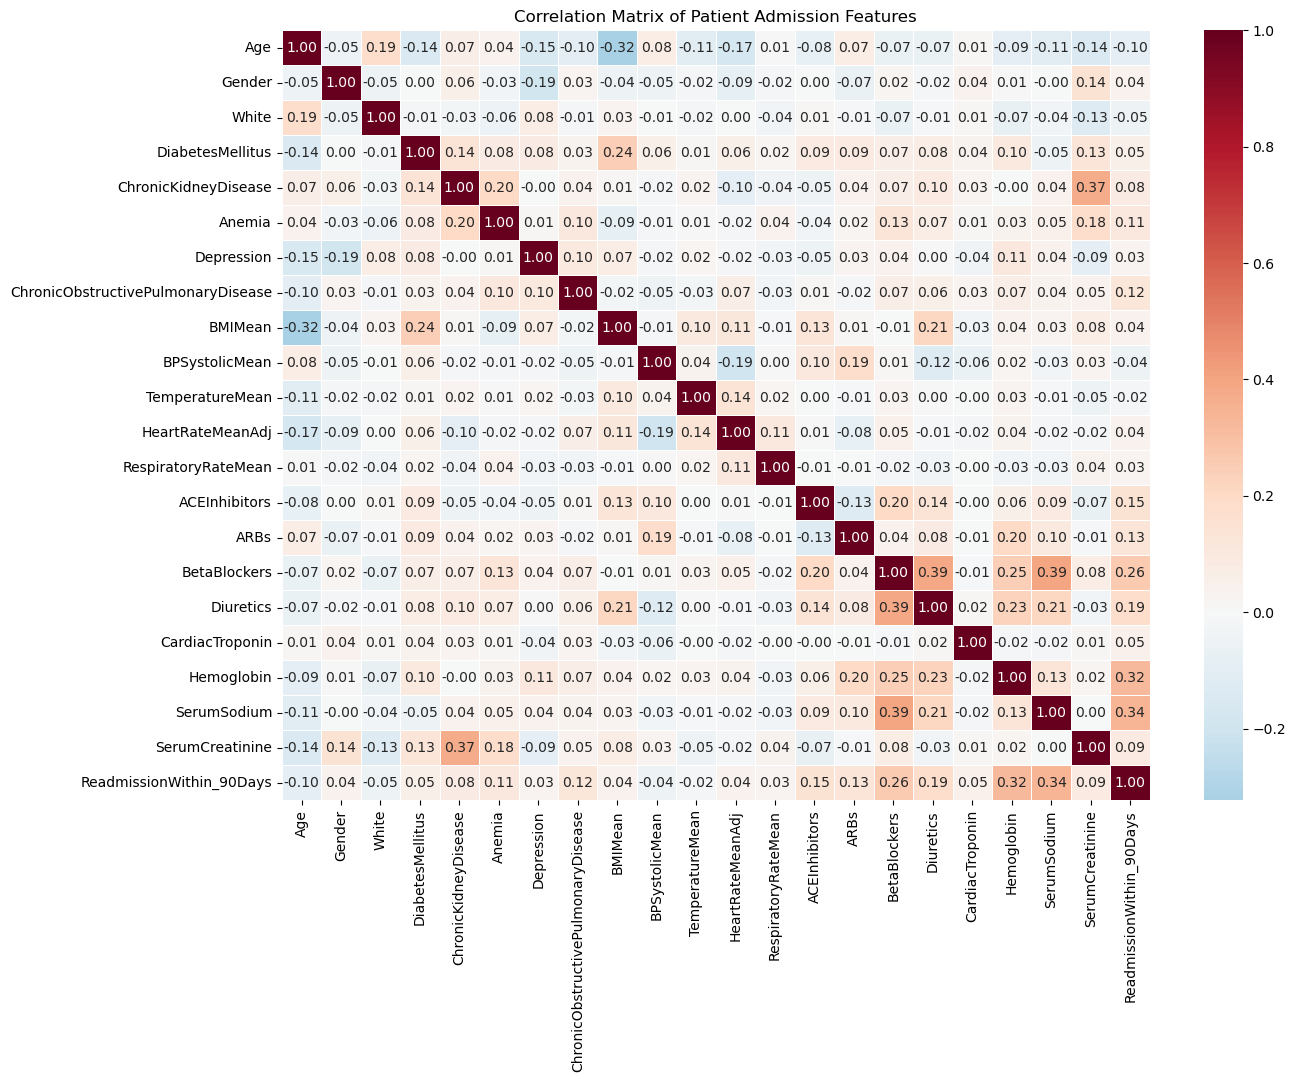

In [19]:
# Calculate the correlation using pearson method
corr_matrix = df.corr()

# Visualization of correlation heatmap
plt.figure(figsize = (14,10))
sns.heatmap(corr_matrix,
            annot = True,
            fmt = ".2f",
            cmap = 'RdBu_r',
            center = 0,
            linewidths = 0.5)

plt.title('Correlation Matrix of Patient Admission Features')
plt.show()

In [20]:
# Necessary libraries for Logistic Regression Model and Confusion Matrix
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LogisticRegression 
from sklearn.compose import ColumnTransformer

In [21]:
# Seperating predictor variables from response to prepare data for model development
X = df.drop('ReadmissionWithin_90Days', axis = 1)
y = df['ReadmissionWithin_90Days']

# Creating Training and test sets
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size = 0.2, random_state = 42)

In [22]:
# Standardizing all variables for X to properly train models
scaler = StandardScaler()

#Fit the training data and transform both
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

In [24]:
# Running the multiple logistic regression model to determine accuracy of method
model = LogisticRegression()
model.fit(X_train_scaled, y_train)
# Accuracy Test
accuracy = model.score(X_test_scaled, y_test)
print(f"The model's accuracy on unseen data is: {accuracy: .2%}")

The model's accuracy on unseen data is:  73.28%


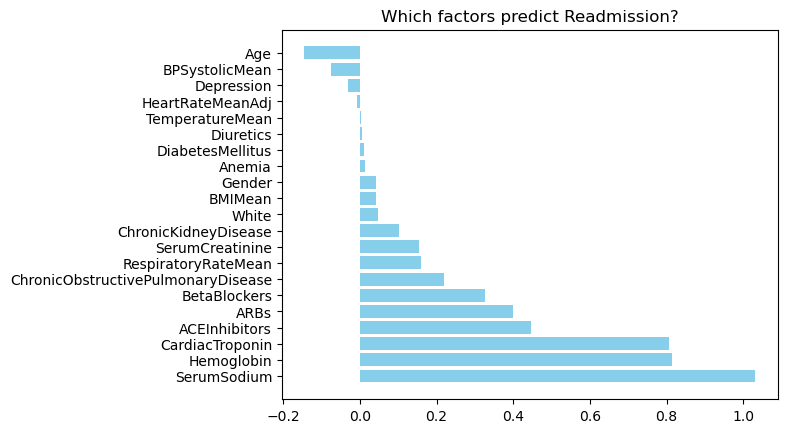

In [25]:
# Identifying coefficient of importance
importance = model.coef_[0]
feature_names = X.columns

# plotting variables
feature_importance = pd.DataFrame({'Feature':feature_names, 'Importance':importance})
feature_importance = feature_importance.sort_values(by = 'Importance', ascending = False)

plt.figure(figure = (10,6))
plt.barh(feature_importance['Feature'], feature_importance['Importance'], color = 'skyblue')
plt.title('Which factors predict Readmission?')
plt.show()

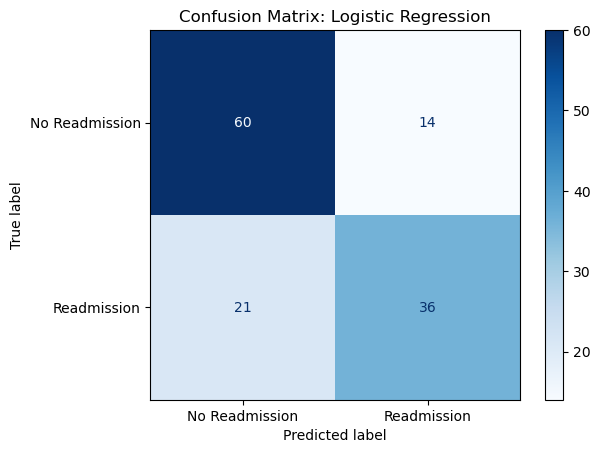

In [26]:
# creating confusion matrix
y_pred = model.predict(X_test_scaled)
cm = confusion_matrix(y_test, y_pred)

# using matplotlib to display findings
disp = ConfusionMatrixDisplay(confusion_matrix = cm, display_labels = ['No Readmission','Readmission'])
disp.plot(cmap = 'Blues')
plt.title('Confusion Matrix: Logistic Regression')
plt.show()

The model is incorrectly predicting 18.9% of the No readmission group, whilte incorrectly predicting 36.8% of the readmission group

In [27]:
from sklearn.metrics import classification_report

In [38]:
# altering threshold of model in an attempt to improve accuracy
y_probs = model.predict_proba(X_test_scaled)[:,1]
threshold = 0.60
y_pred_custom = (y_probs >= threshold).astype(int)

# Check the new Confusion Matrix
new_cm = confusion_matrix(y_test, y_pred_custom)
print("Confusion Matrix at 0.6 Threshold:")
print(new_cm)

Confusion Matrix at 0.6 Threshold:
[[65  9]
 [25 32]]


In [41]:
import statsmodels.api as sm

# Creating a data frame with the data to check statistical significance
X_train_scaled_df = pd.DataFrame(X_train_scaled, columns = X.columns)

X_train_const = sm.add_constant(X_train_scaled_df)

# Fitting the logit model 
logit_model = sm.Logit(y_train.reset_index(drop = True), X_train_const)
result = logit_model.fit()

# Printing result to interpret values
print(result.summary())

Optimization terminated successfully.
         Current function value: 0.497493
         Iterations 15
                              Logit Regression Results                              
Dep. Variable:     ReadmissionWithin_90Days   No. Observations:                  521
Model:                                Logit   Df Residuals:                      499
Method:                                 MLE   Df Model:                           21
Date:                      Fri, 13 Feb 2026   Pseudo R-squ.:                  0.2823
Time:                              09:52:55   Log-Likelihood:                -259.19
converged:                             True   LL-Null:                       -361.13
Covariance Type:                  nonrobust   LLR p-value:                 6.266e-32
                                         coef    std err          z      P>|z|      [0.025      0.975]
------------------------------------------------------------------------------------------------------
const      

In [53]:
# running a logistic regression with only statistically significant values to test accuracy of the altered model
df2 = df.copy()
df2 = df2.drop(['Age','Gender','White','DiabetesMellitus','ChronicKidneyDisease','Anemia','Depression','BMIMean',
          'BPSystolicMean','TemperatureMean','HeartRateMeanAdj','RespiratoryRateMean','Diuretics','SerumCreatinine'], axis = 1)

In [55]:
X = df2.drop('ReadmissionWithin_90Days', axis = 1)
y = df2['ReadmissionWithin_90Days']
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size = 0.2, random_state = 42)
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

# Running the multiple logistic regression with specific variables
model = LogisticRegression()
model.fit(X_train_scaled, y_train)
# Testing the accuracy of the new models
accuracy = model.score(X_test_scaled, y_test)
print(f"The model's accuracy on unseen data is: {accuracy: .2%}")

The model's accuracy on unseen data is:  73.28%


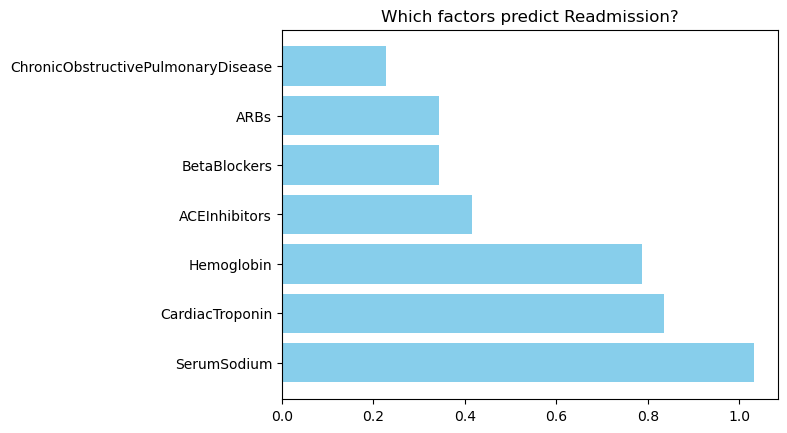

In [57]:
# Identifying coefficient of importance
importance = model.coef_[0]
feature_names = X.columns

# plotting variables with their importance to the new model
feature_importance = pd.DataFrame({'Feature':feature_names, 'Importance':importance})
feature_importance = feature_importance.sort_values(by = 'Importance', ascending = False)

plt.figure(figure = (10,6))
plt.barh(feature_importance['Feature'], feature_importance['Importance'], color = 'skyblue')
plt.title('Which factors predict Readmission?')
plt.show()

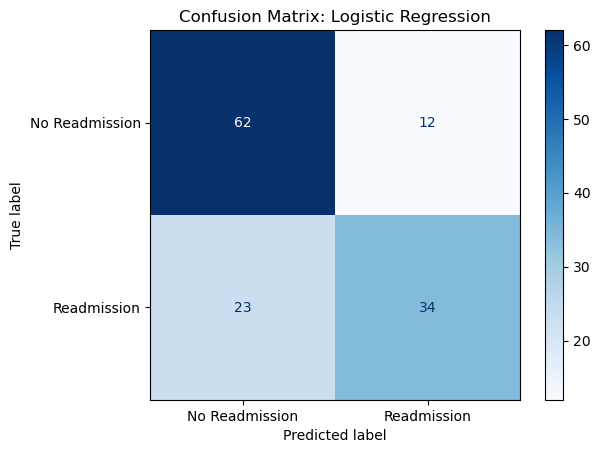

In [58]:
# Confusion Matrix to understand precision
y_pred = model.predict(X_test_scaled)
cm = confusion_matrix(y_test, y_pred)
disp = ConfusionMatrixDisplay(confusion_matrix = cm, display_labels = ['No Readmission','Readmission'])
disp.plot(cmap = 'Blues')
plt.title('Confusion Matrix: Logistic Regression')
plt.show()

Although accuracy remained the same, the confusion matrix indicates that the prediction power of non readmissioned increase while readmissioned decreased in power. 

In [60]:
# Changing the model to the original with more dispussion in accuracy
X = df.drop('ReadmissionWithin_90Days', axis = 1)
y = df['ReadmissionWithin_90Days']
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size = 0.2, random_state = 42)
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)
model = LogisticRegression()
model.fit(X_train_scaled, y_train)

LogisticRegression()

In [61]:
from sklearn.ensemble import RandomForestClassifier

# Creating a random forest model to check accuracy of this method on prediction
rf_model = RandomForestClassifier(n_estimators=100, max_depth=3, random_state=42)
rf_model.fit(X_train, y_train) 

y_pred_rf = rf_model.predict(X_test)

print("Random Forest Results:")
print(confusion_matrix(y_test, y_pred_rf))
print(classification_report(y_test, y_pred_rf))

Random Forest Results:
[[59 15]
 [20 37]]
              precision    recall  f1-score   support

           0       0.75      0.80      0.77        74
           1       0.71      0.65      0.68        57

    accuracy                           0.73       131
   macro avg       0.73      0.72      0.73       131
weighted avg       0.73      0.73      0.73       131



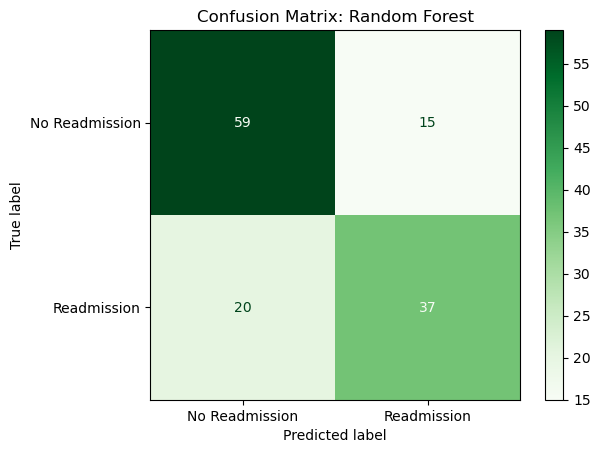

In [62]:
# displaying the confusion matrix of random forest to check precision
y_pred_rf = rf_model.predict(X_test)
cm_rf = confusion_matrix(y_test, y_pred_rf)

# Plot Random Forest Matrix
disp_rf = ConfusionMatrixDisplay(confusion_matrix = cm_rf, display_labels = ['No Readmission','Readmission'])
disp_rf.plot(cmap = 'Greens')
plt.title('Confusion Matrix: Random Forest')
plt.show()

In [63]:
#importance of random forest
importances = rf_model.feature_importances_
feature_names = X.columns

# Dataframe for ranking
rf_importance = pd.DataFrame({'Feature': feature_names, 'Importance':importances})

#sort importance
rf_importance = rf_importance.sort_values(by='Importance', ascending = False)

# Display the Top 15
print(rf_importance.head(15))

                               Feature  Importance
19                         SerumSodium    0.187179
15                        BetaBlockers    0.173119
18                          Hemoglobin    0.164710
17                     CardiacTroponin    0.102639
16                           Diuretics    0.056172
13                       ACEInhibitors    0.047985
14                                ARBs    0.045705
0                                  Age    0.038095
11                    HeartRateMeanAdj    0.033031
20                     SerumCreatinine    0.030501
12                 RespiratoryRateMean    0.030425
9                       BPSystolicMean    0.024798
7   ChronicObstructivePulmonaryDisease    0.019607
10                     TemperatureMean    0.019308
8                              BMIMean    0.015375


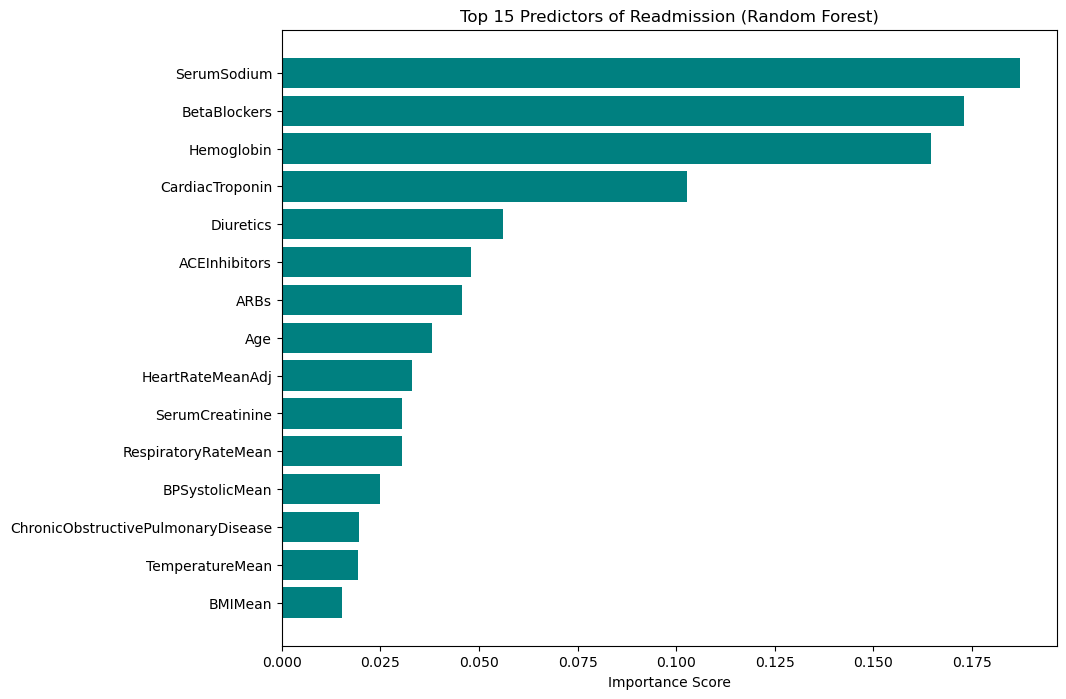

In [64]:
# plotting individual variables of importance for the random forest model
plt.figure(figsize=(10, 8))
plt.barh(rf_importance['Feature'].head(15), rf_importance['Importance'].head(15), color='teal')
plt.xlabel('Importance Score')
plt.title('Top 15 Predictors of Readmission (Random Forest)')
plt.gca().invert_yaxis() # Highest importance at the top
plt.show()

In [68]:
# Defining a risk calculator for readmission using random forest model
def readmission_risk_calc(patient_data):
    patient_df = pd.DataFrame([patient_data])
    probability = rf_model.predict_proba(patient_df)[0][1]
    return probability

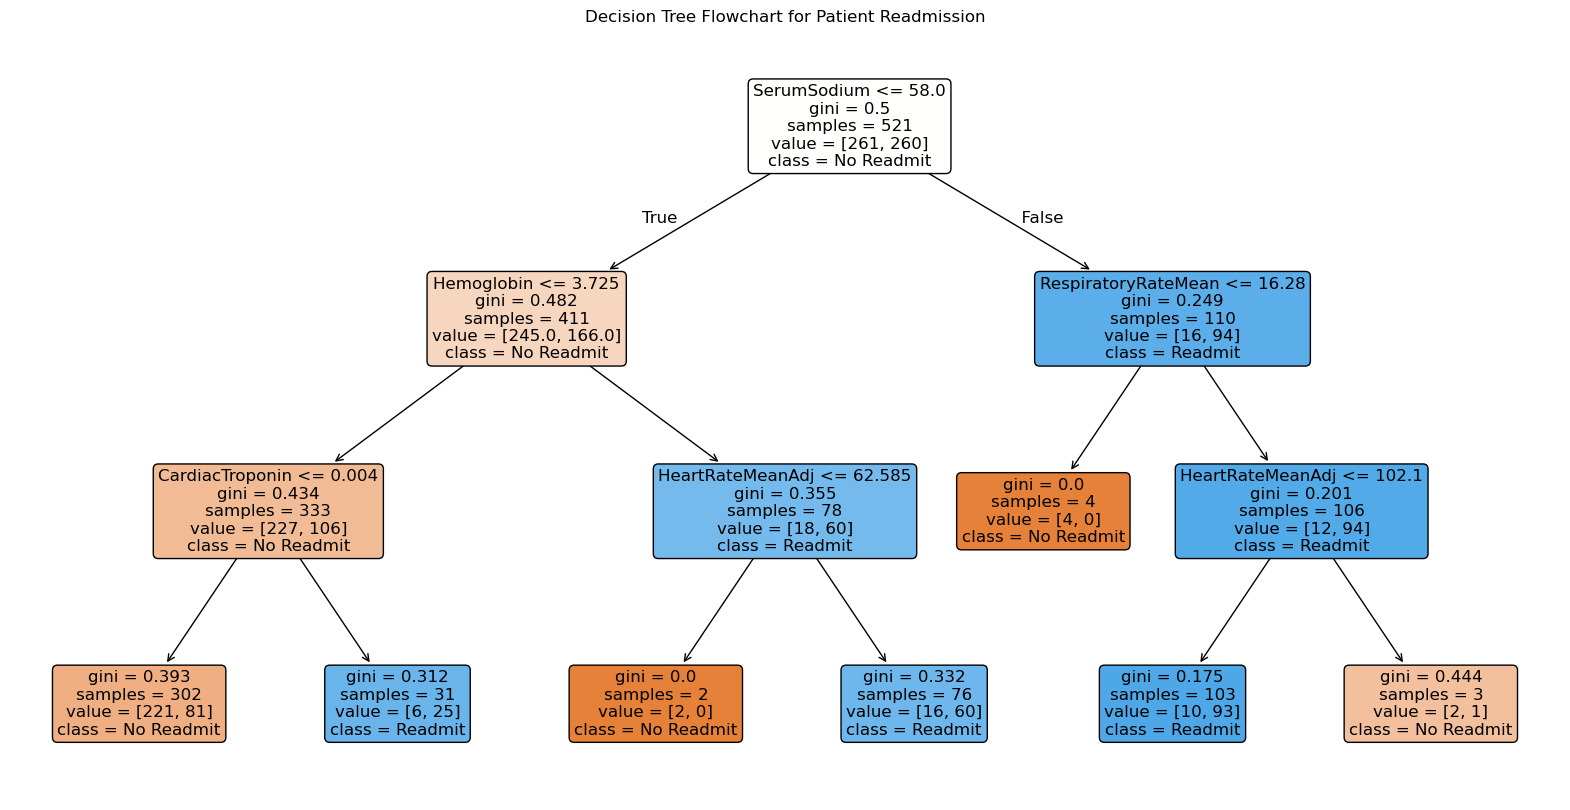

In [70]:
from sklearn.tree import DecisionTreeClassifier, plot_tree

# plotting a decision tree to visualize logic behind tree models on data
dt_model = DecisionTreeClassifier(max_depth=3, random_state=42)
dt_model.fit(X_train, y_train)

plt.figure(figsize=(20,10))
plot_tree(dt_model, 
          feature_names=X.columns,  
          class_names=['No Readmit', 'Readmit'],
          filled=True,            
          rounded=True, 
          fontsize=12)
plt.title("Decision Tree Flowchart for Patient Readmission")
plt.show()

# Concluding remarks:

The final analysis indicates that while a predictive model can be established, it is limited to an accuracy of approximately 73% given the current dataset.

Data quality issues, such as 'placeholder' or missing values (Mean Heart Rate recorded as 0), introduced noise that hinders the algorithm's predictive power. Therefore, some observations were removed to improve accuracy of models, however, with such a practice variables that could hold values of 0 could lead to training error. Being able to identify the difference between a health metric of 0 and a place hold is vital, requiring a need for better practice in data collection.


To improve the reliability of the Risk Calculator, future iterations require more robust data collection and a larger sample size for younger demographics to ensure model completeness. Consequently, this project serves as a foundational proof-of-concept for a geriatric-focused risk tool. 